# Домашнее задание 8. Мониторинг

Прослеживаемость конвейера (и кода, и данных) должна закладываться **до проектирования** (в идеале, на основе синтезированного трафика от системы нагрузочного тестирования Locust/k6s/ab/...).


## 1. Определить ключевые бизнес- и технические метрики для ML-системы

Чтобы разработка могла сдвинуться с мертвой точки, создайте сбаланисированное дерево метрик, которое бы учитывало точки зрения разных команд.


|Требования бизнеса|Требования разработчиков|Требования команды ML|Требования DevOps|
|------------------|------------------------|---------------------|-----------|
|Нужно увеличить выручку онлайн-кинотеатра|Нужен новый сервер |Нужен GPU      | Вы существующие мощности недогружаете |
|...пиковая нагрузка 10000 RPS|Нужно переходить на ClickHouse? |Сколько фильмов выводить для рекомендательной системы?      |Есть Postgres, он выдает 1000 RPS, потому что мы обернули Docker-in-Docker         |
|...и чтобы быстрый был|Нужно переписать бэкенд?|Нужно переходить на стримы? | Какое нужно время отклика? |
|...и чтобы надежный был| Сделать на Kubernetes? |Сделать на KubeFlow? | SLA 100% нет даже на бирже  |

Желательно использовать [adr-tools](https://github.com/npryce/adr-tools), чтобы записывать **причины**, по которым мы начали принимать решения и **риски**, из-за которых ML-система может работать не так, как ожидается.


*Ожидаемый артефакт: создающий диаграмму код в [ячейке](#scrollTo=y2v5KaAkw0zx)*

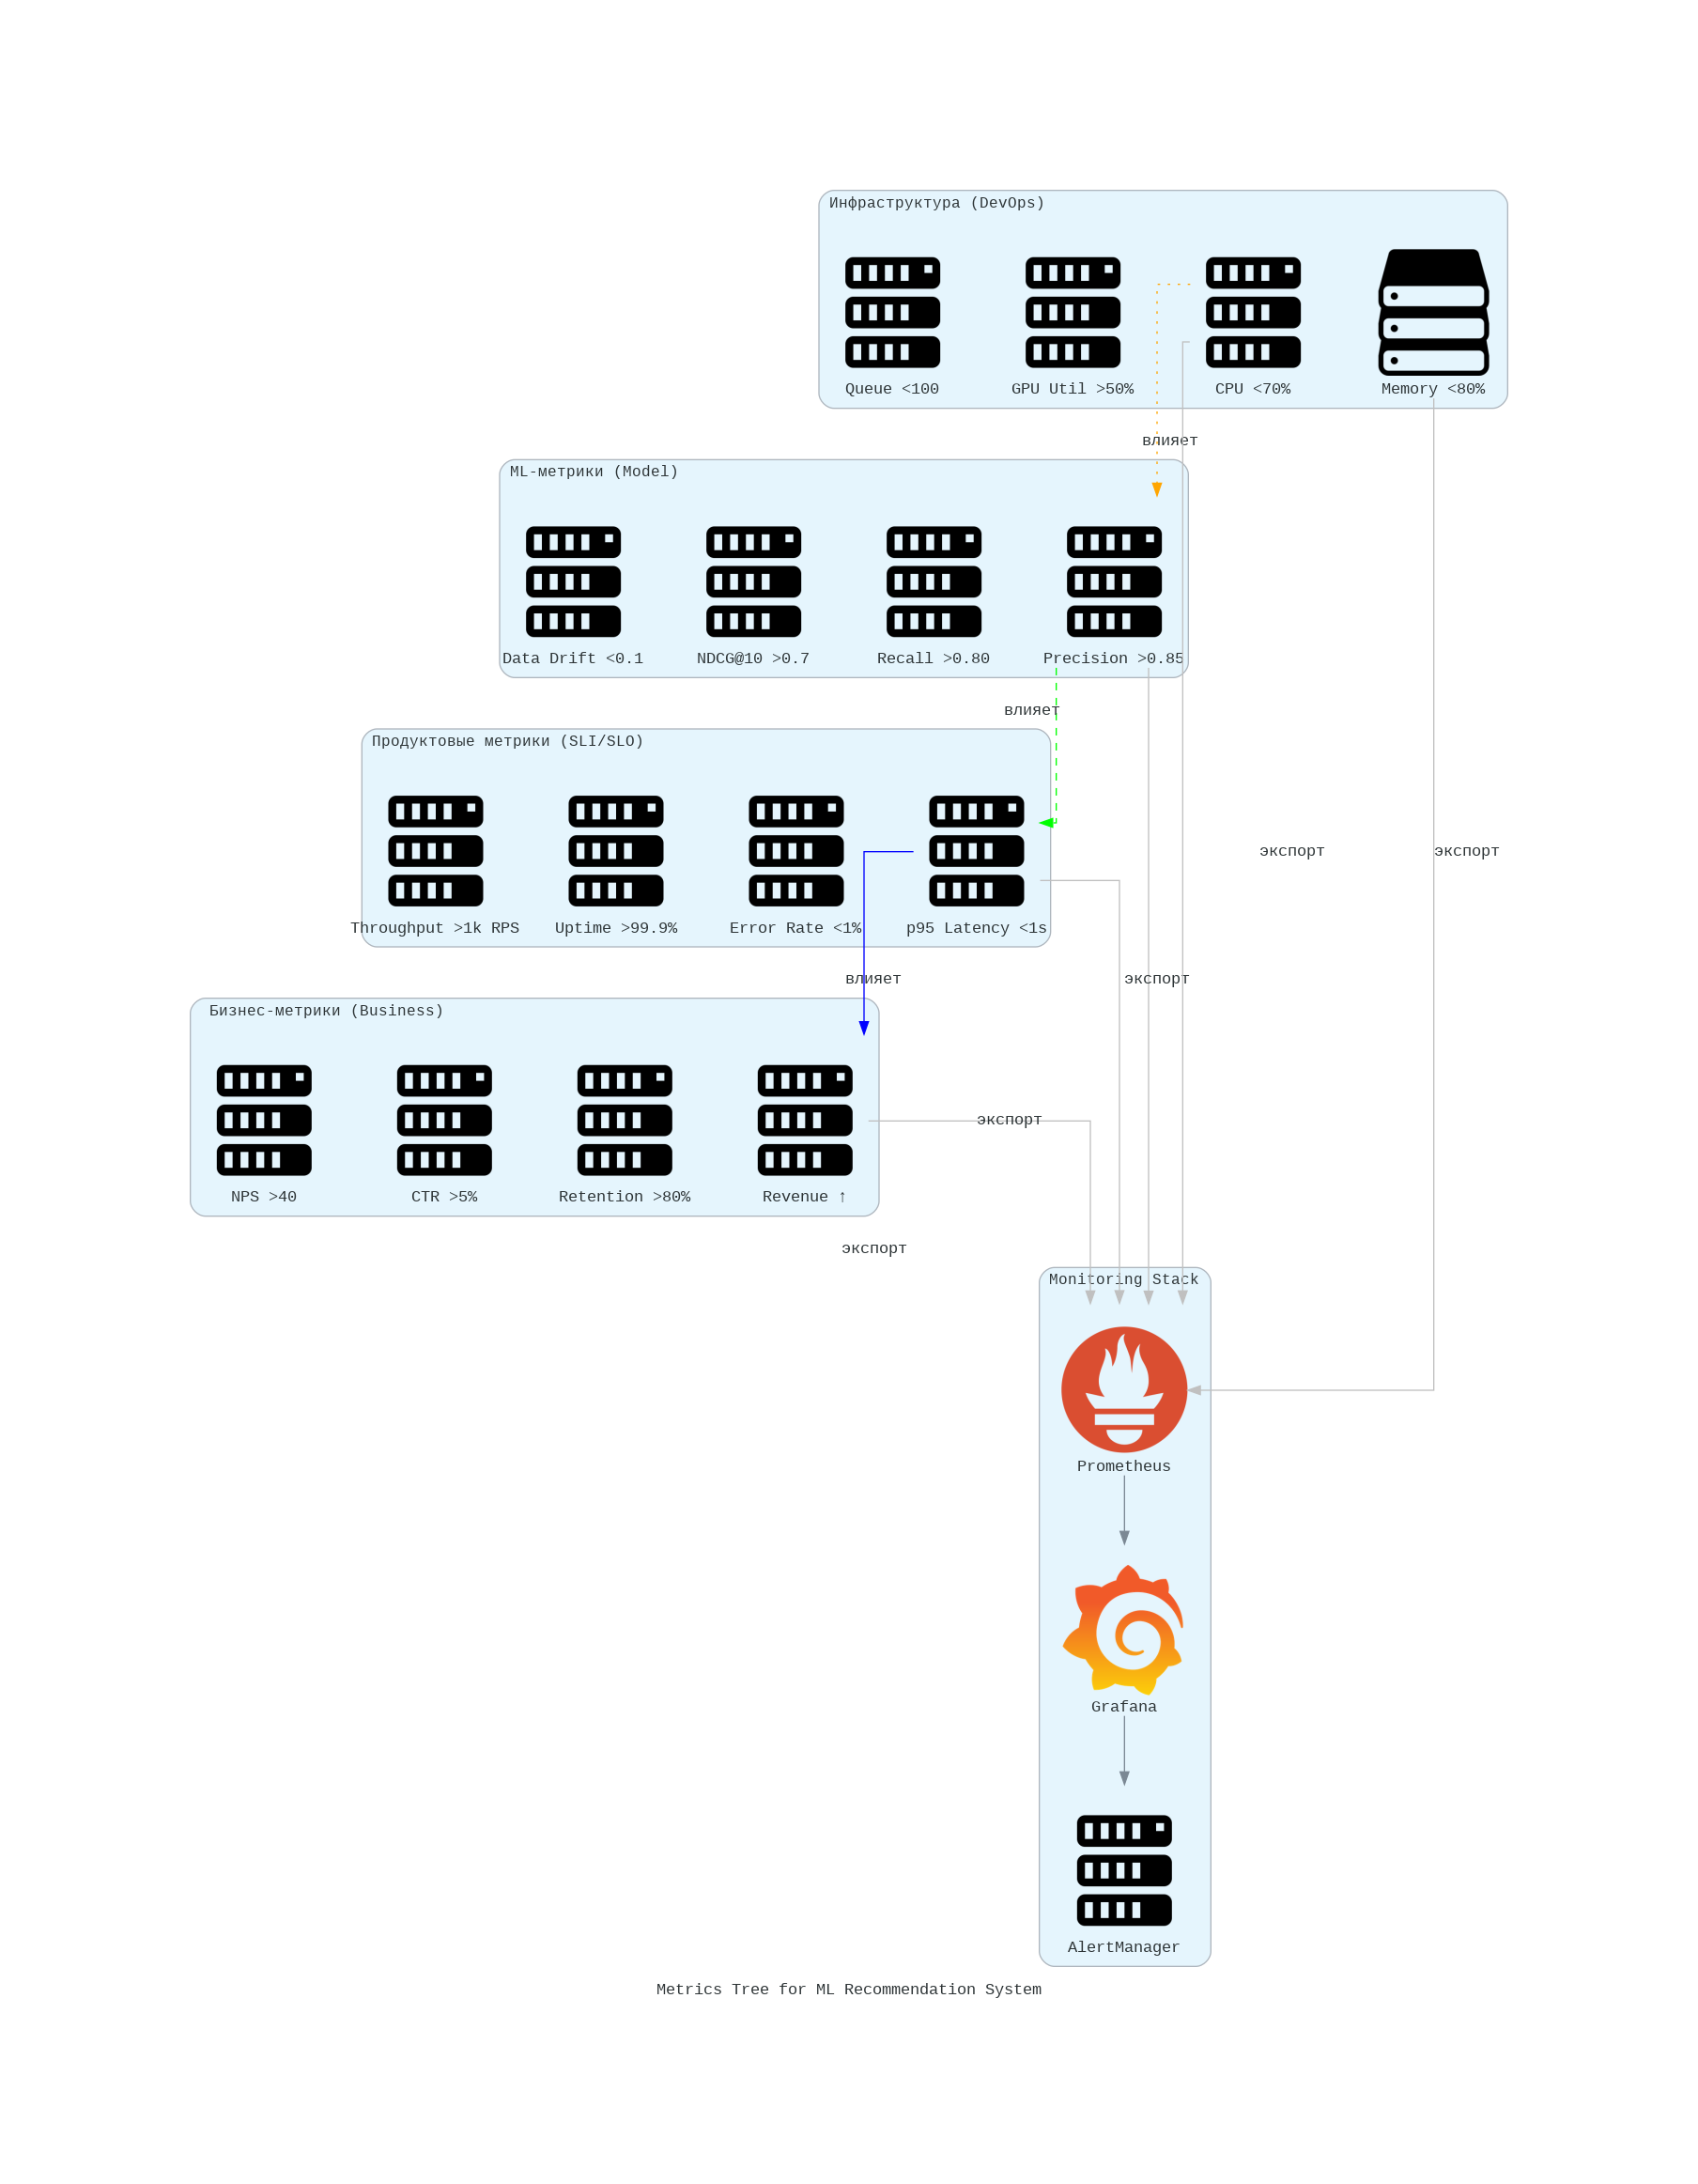

In [1]:
!pip install diagrams --upgrade -q >/dev/null 2>&1
!apt-get install -y graphviz >/dev/null 2>&1
from diagrams import Diagram, Cluster, Edge
from diagrams.onprem.compute import Server
from diagrams.onprem.monitoring import Grafana, Prometheus
from diagrams.generic.storage import Storage
from IPython.display import Image, display

graph_attr = {
    "fontsize": "13",
    "bgcolor": "white",
    "spacing": "0.8",
    "splines": "ortho"
}

with Diagram("Metrics Tree for ML Recommendation System",
           filename="metrics_tree_v2",
           direction="TB",
           show=False,
           graph_attr=graph_attr) as diag:

    with Cluster(" Бизнес-метрики (Business)"):
        revenue = Server("Revenue ↑")
        retention = Server("Retention >80%")
        ctr = Server("CTR >5%")
        nps = Server("NPS >40")
        biz = [revenue, retention, ctr, nps]

    with Cluster("Продуктовые метрики (SLI/SLO)"):
        latency = Server("p95 Latency <1s")
        error = Server("Error Rate <1%")
        uptime = Server("Uptime >99.9%")
        rps = Server("Throughput >1k RPS")
        app = [latency, error, uptime, rps]

    with Cluster("ML-метрики (Model)"):
        precision = Server("Precision >0.85")
        recall = Server("Recall >0.80")
        ndcg = Server("NDCG@10 >0.7")
        drift = Server("Data Drift <0.1")
        ml = [precision, recall, ndcg, drift]

    with Cluster("Инфраструктура (DevOps)"):
        cpu = Server("CPU <70%")
        mem = Storage("Memory <80%")
        gpu = Server("GPU Util >50%")
        queue = Server("Queue <100")
        infra = [cpu, mem, gpu, queue]

    with Cluster("Monitoring Stack"):
        prom = Prometheus("Prometheus")
        graf = Grafana("Grafana")
        alert = Server("AlertManager")

    latency >> Edge(color="blue", label="влияет") >> revenue
    precision >> Edge(color="green", label="влияет", style="dashed") >> latency
    cpu >> Edge(color="orange", label="влияет", style="dotted") >> precision

    for node in [revenue, latency, precision, cpu, mem]:
        node >> Edge(color="gray", label="экспорт") >> prom

    prom >> graf >> alert

display(Image(filename="metrics_tree_v2.png", width=900))

## 2. Настроить мониторинг с использованием Prometheus, Grafana, MLflow


Желательно (но не обязательно) ознакомиться с инициативой по стандартизации [метрик](https://github.com/OpenSLO/OpenSLO), можно попробовать редактировать в [онлайн-редакторе](https://live.sloth.dev/?slo-spec=G4UwTgzglg9gdgLgAQCIAOYYFsQBcAWIArhAPTACMKAUBOMFAMYjIpYCedYDzNANgEMARiD4QE1JEhgB3OOFYdcIAVhpSwINDEXsYYAOakOXHiHVJcUBagBMNCHxjjJSAMRIA6iCQC+TmSQAMwEoPig4AyQACgBWAA943zgAEyQAFlsATgBKJAokTQBHIhAIXCQQUDB2fIAGBsKQErLcCBisrIA6LIBSHK7XAFokOFUWVGLS8oghgWBQwSEwqFx2CykYIQArEEYrUGROntcpFLLGMCg0K3hWAGFsLHgkAGUAGQB5JCEBOjSXvNFsIVmtgvokAAJAAq0IACk0WuUmhBtHA6BAuhskI4oBIpATKqA4G18YSCeBMGAAPotGrICBELDRMACZTRfC4XBoalTVrUlJEVm3ODUuiMeApCDUiVEEkAb22WwAvGxOPQmOYADQS87KgB+KDiXS6AB9MrkUABfADa8vlXRkERSsitVoAujkcqdybgYLg-LTSvScUyWWyQByuTy+eUBUK2bBReLJdLZQqlUJVSYNbxbfbHc7XR6vT6-OArJEyYSxjhkABZdivXMgSFQAz4ACiYCpACUIz6pEtRC5yQTGBGDPp2KwgWEQeE1tipAI4HB-Yn4KOx+4kJ9qjIrsokOcQkQ+BVXk4CG8vr4+BXQ1hnwIatI4JYmABrPDJNJoAQDB8cswDaQYdyfLBXxnVA2w7SoewhYUfBeAByHNuE1VDEWmNoUTRDFlyQACgOpEDcGrclhzESixzoapVhgki8BULBB3JTAiErAxqR-GClFY9irEYH9cDIh9QNoglqO3CD6PARjWEcAQRKIwllJEmV8FXeQ+FYNxyNmATVBQIA)


Принимая во внимание дерево метрик, выбранных в предыдущей [ячейке](#scrollTo=64bcf49d), нужно выбрать **одну** метрику и поставить ее на мониторинг.


*Ожидаемый артефакт: yaml в [ячейке](#scrollTo=Q0xhdA3Sw1XY) дашборд в [ячейке](#scrollTo=s7cw3qhud3Dx)*


In [2]:
%%writefile prometheus.yml

global:
  scrape_interval: 15s
  evaluation_interval: 15s

rule_files:
  - "alert_rules.yml"

scrape_configs:
  - job_name: "ml_service"
    metrics_path: /metrics
    scheme: http
    static_configs:
      - targets: ["localhost:8000"]
    scrape_timeout: 10s

Overwriting prometheus.yml


In [3]:
%%writefile grafana.json

{
  "annotations": {"list": []},
  "editable": true,
  "fiscalYearStartMonth": 0,
  "graphTooltip": 0,
  "id": null,
  "links": [],
  "liveNow": false,
  "panels": [
    {
      "datasource": {"type": "prometheus", "uid": "prometheus"},
      "fieldConfig": {
        "defaults": {
          "color": {"mode": "palette-classic"},
          "custom": {
            "axisCenteredZero": false,
            "axisColorMode": "text",
            "axisLabel": "",
            "axisPlacement": "auto",
            "barAlignment": 0,
            "drawStyle": "line",
            "fillOpacity": 10,
            "gradientMode": "none",
            "hideFrom": {"legend": false, "tooltip": false, "viz": false},
            "lineInterpolation": "linear",
            "lineWidth": 2,
            "pointSize": 5,
            "scaleDistribution": {"type": "linear"},
            "showPoints": "never",
            "spanNulls": true,
            "stacking": {"group": "A", "mode": "none"},
            "thresholdsStyle": {"mode": "line"}
          },
          "mappings": [],
          "thresholds": {
            "mode": "absolute",
            "steps": [
              {"color": "green", "value": null},
              {"color": "red", "value": 1.0}
            ]
          },
          "unit": "s"
        },
        "overrides": []
      },
      "gridPos": {"h": 8, "w": 12, "x": 0, "y": 0},
      "id": 1,
      "options": {
        "legend": {"calcs": [], "displayMode": "list", "placement": "bottom"},
        "tooltip": {"mode": "single", "sort": "none"}
      },
      "targets": [
        {
          "datasource": {"type": "prometheus", "uid": "prometheus"},
          "expr": "histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket[5m])) by (le))",
          "legendFormat": "p95 latency",
          "refId": "A"
        }
      ],
      "title": "p95 Request Latency (SLO < 1s)",
      "type": "timeseries"
    },
    {
      "datasource": {"type": "prometheus", "uid": "prometheus"},
      "fieldConfig": {
        "defaults": {
          "color": {"mode": "thresholds"},
          "mappings": [],
          "thresholds": {
            "mode": "absolute",
            "steps": [
              {"color": "green", "value": null},
              {"color": "red", "value": 1.0}
            ]
          },
          "unit": "s"
        },
        "overrides": []
      },
      "gridPos": {"h": 4, "w": 4, "x": 12, "y": 0},
      "id": 2,
      "options": {
        "colorMode": "value",
        "graphMode": "area",
        "justifyMode": "auto",
        "orientation": "auto",
        "reduceOptions": {
          "calcs": ["lastNotNull"],
          "fields": "",
          "values": false
        },
        "textMode": "auto"
      },
      "targets": [
        {
          "expr": "histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket[5m])) by (le))",
          "refId": "A"
        }
      ],
      "title": "Current p95",
      "type": "stat"
    }
  ],
  "refresh": "5s",
  "schemaVersion": 38,
  "style": "dark",
  "tags": ["ml-monitoring", "slo"],
  "templating": {"list": []},
  "time": {"from": "now-15m", "to": "now"},
  "timepicker": {},
  "timezone": "",
  "title": "ML Service - Latency SLO",
  "uid": "ml_latency_slo",
  "version": 1,
  "weekStart": ""
}

Overwriting grafana.json


In [4]:
%%writefile alert_rules.yml
groups:
  - name: ml_service_alerts
    rules:
      - alert: HighLatency
        expr: histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket[5m])) by (le)) > 1
        for: 2m
        labels:
          severity: warning
          service: ml_recommendation
        annotations:
          summary: "High request latency detected"
          description: "p95 latency exceeded 1s for more than 2 minutes. Current value: {{ $value }}s"
          runbook_url: "https://wiki.example.com/runbooks/high-latency"

Overwriting alert_rules.yml


## 3. Обнаружить деградацию модели и дрифт

Вспомните материалы [семинара](https://colab.research.google.com/drive/1OVBFG3bRLmmmVj31Ob5LFhKQTAi7f-Hn?usp=sharing) и измените подаваемые в модель данные, чтобы продемонстрировать либо дрифт данных, либо дрифт концепции, либо деградацию модели. Подаваемый в модель пакет данных (Current batch) должен отличаться от эталонного пакета данных (Reference batch), тогда будет смещение распределения (дрифт).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=lq14Cx_GxYSM)*


In [5]:
!pip install evidently -q
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset
from IPython.display import display, HTML

np.random.seed(42)
X_ref, _ = make_classification(n_samples=500, n_features=4, n_informative=2, random_state=42)
reference = pd.DataFrame(X_ref, columns=['feature_0', 'feature_1', 'feature_2', 'feature_3'])

X_curr, _ = make_classification(n_samples=500, n_features=4, n_informative=2, random_state=99)
current = pd.DataFrame(X_curr, columns=['feature_0', 'feature_1', 'feature_2', 'feature_3'])

current['feature_0'] = current['feature_0'] * 2.5 + 4.0
current['feature_1'] = current['feature_1'] + np.random.normal(0, 1.5, 500)

data_report = Report(metrics=[DataDriftPreset()])
data_report.run(reference_data=reference, current_data=current)

data_report

## 4. Обеспечить качество данных с Data Quality Ops

1) Запустите центр управления качеством данных:

```bash
apt install python3-pip -y
pip install --user dqops
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"
python -m dqops
```
2) Перейдите в браузер на порту 8080 и подключитесь к источнику (MySQL/PostgreSQL).
3) Создайте таблицу в базе данных.
4) Импортируйте таблицу из базы данных в DQOps.
5) Измените структуру столбцов таблицы в базе данных.
6) Перейдите на вкладку Incidents в DQOps.
7) Подтвердите наличие инцидента с качеством данных и сделайте скриншот.



*Ожидаемый артефакт: SQL код, вызвавший инцидент в [ячейке](#scrollTo=G2O81Sl3w3Tb)*


In [6]:
%%sh
apt install python3-pip -y /dev/null
pip install --user dqops -qqq
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"

Reading package lists...
Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y




E: Unsupported file /dev/null given on commandline


In [7]:
from google.colab import userdata
import os
os.environ["tunatoken"] = userdata.get('tuna')
!curl -sSLf https://get.tuna.am | sh >/dev/null
!tuna config save-token $tunatoken
!echo "Скопируйте строку ниже, вставьте его в терминал, нажмите Enter"
!sleep 5 && nohup python -m dqops --host 0.0.0.0 --port 8080 & tuna http 8080 & wait

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
INFO[18:23:38] Token saved                                  
Скопируйте строку ниже, вставьте его в терминал, нажмите Enter
INFO[18:23:38] Welcome to Tuna                              
INFO[18:23:39] Account: ivashko.daniil@gmail.com (Free)     
INFO[18:23:39] Web Interface: http://127.0.0.1:4040         
INFO[18:23:41] Forwarding https://f5rvmy-34-24-108-18.ru.tuna.am -> 127.0.0.1:8080 
nohup: appending output to 'nohup.out'
INFO[18:23:51] Bye                                          
^C


In [8]:
#SQL
CREATE TABLE IF NOT EXISTS user_events (
    event_id SERIAL PRIMARY KEY,
    user_name VARCHAR(100),
    event_type VARCHAR(50),
    amount DECIMAL(10,2),
    created_at TIMESTAMP DEFAULT NOW()
);

ALTER TABLE user_events RENAME COLUMN user_name TO client_name;
ALTER TABLE user_events ADD COLUMN device_type VARCHAR(50) DEFAULT 'web';


SyntaxError: invalid syntax (455333320.py, line 2)

## 5. Разработать схему ML-системы для Virtual Product Placement

Речь о том, когда цифровая реклама с помощью генеративного ИИ встраивает бренды в видеопоток.


**Вводные данные от бизнеса: нужно показывать клиентам видео с похожими на них персонажами с логотипом на футболке + пример видеоданных.**

*Закон нужно соблюдать всегда: не занимайтесь созданием дипфейков, скоро за это будет введено серьезное [наказание](https://sozd.duma.gov.ru/bill/718538-8).

Вспомните [семинар](https://colab.research.google.com/drive/1xkEK73u65oxzABCzHfQ7-QXVUeXSqfmo?usp=sharing) про сравнение архитектур Lambda и Kappa, обратите внимание на стримы в коде @broker.subscriber("channel1")
и @broker.publisher("channel1").

Нужно выбрать оптимальную архитектуру и составить схематическое описание ML-системы с помощью библиотеки [Diagrams](https://diagrams.mingrammer.com).



*Ожидаемый артефакт: код, создающий диаграмму в [ячейке](#scrollTo=v7M9wJYvrUhL)*

%%html

Нижеприведенный код проектируемой ML-системы обрабатывает каждый кадр видео сначала дискриминативным ИИ, затем дорисовывает изображение генеративным ИИ:

<table >
		<tr>
			<td>
        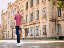
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
			<td>
        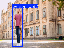
      </td>
      <td align=""center>
        <font size="96px">
        &#11015;
        </font>
      </td>
			<td>
        Дискриминативная нейросеть
      </td>
      <td>
        <img src="" />
      </td>
      <td>
        <img src="" />
      </td>
		</tr>
		<tr>
			<td>
        <img src="" />
      </td>
      <td>
      Генеративная нейросеть
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        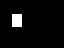
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
      <td>
        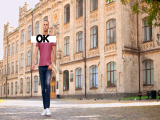
      </td>
		</tr>
</table>

In [9]:
!pip install ultralytics gdown tqdm -qqq

from IPython import display
display.clear_output()
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

from IPython.display import display, clear_output, Image
import os
import gdown
import cv2

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.0/112.6 GB disk)


In [10]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1aNzbaXvasI1Ealcq3m-0mBGPpRvrJs70'
gdown.download(gdrive_url, quiet=True); Video("/content/HW8_building_and_person.mp4",embed=True, width=640, height=360)

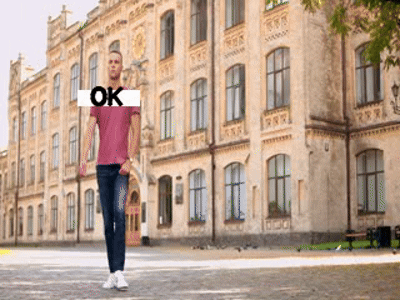

In [12]:
gdrive_url = 'https://drive.google.com/uc?export=download&id=1wKODx-KPHgSnY6HttStOXJZa3Fr6vBZn'
gdown.download(gdrive_url, quiet=True); Image("/content/HW8_building_and_person_processed.gif", width=640, height=360)

In [11]:
%%capture
!apt-get update
!apt-get install -y redis-server
!redis-server --daemonize yes # Запуск Redis в фоновом режиме
!redis-server --version
!pip install 'faststream[redis]' asyncio

In [13]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
import nest_asyncio
nest_asyncio.apply()
from faststream import FastStream
from faststream.redis import RedisBroker
import asyncio

model = YOLO("yolo11n.pt")          #стратегия загрузки Warm

output_video_path = '/content/building_and_person-processed.mp4'
video_file_path = "/content/HW8_building_and_person.mp4"
video_capture = cv2.VideoCapture(video_file_path)

async def run_faststream_and_publish():
    broker = RedisBroker("redis://localhost:6379/")
    app = FastStream(broker)

    @broker.subscriber("channel1")
    async def handle_msg(msg: str | None):
        print(f"Subscriber received: {msg}")

    @broker.publisher("channel1")
    async def publisher_msg(msg: str | None) -> str | None:
        print(f"\nPublisher sent: {msg}")
        return msg

    consumer_task = asyncio.create_task(app.start())
    publisher_task = asyncio.create_task(app.start())

    await asyncio.sleep(1) # Give brokers time to start

    if not video_capture.isOpened():
        print("Error: Could not open video file.")
    else:
        fps = int(video_capture.get(cv2.CAP_PROP_FPS))
        width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
        black_mask = np.zeros((height, width, 3), dtype=np.uint8)
        frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

        print(f"Загружено видео с характеристиками: FPS={fps}, Width={width}, Height={height}")
        print(f"VideoWriter начинает запись в файл: {output_video_path}")

        video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)
        with tqdm(total=frame_count, desc="обработано ") as pbar:
          while video_capture.isOpened():
              ret, frame = video_capture.read()
              if not ret:
                  break
              pbar.update(1)

              results = model(frame)
              annotated_frame = results[0].plot()
              await publisher_msg("<-новый кадр")

              image_with_box = frame.copy()

              for result in results:
                  xywh = result.boxes.xywh  # center-x, center-y, width, height
                  names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
                  if 'person' in names:
                      index = names.index('person')
                      x_center, y_center, box_w, box_h = map(int, xywh[index].tolist())

                      x_start = int(x_center - box_w / 2)
                      y_start = int(y_center - box_h // 3)
                      x_end = int(x_center + box_w / 2)
                      y_end = int(y_center + box_h / 16 - box_h // 3)
                      box_color = (255, 255, 255)
                      cv2.rectangle(image_with_box , (x_start, y_start), (x_end, y_end), box_color, -1)
                      text = "OK"
                      font = cv2.FONT_HERSHEY_SIMPLEX
                      font_scale = 0.6
                      font_thickness = 2
                      text_color = (0, 0, 0)

                      (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

                      text_x =  (x_start + x_end) //2 - ( text_width) // 2
                      text_y =  (y_start + y_end) //2 +5

                      cv2.putText(image_with_box, text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

              video_writer.write(image_with_box)

        video_capture.release()
        video_writer.release()

    # Cancel tasks to properly stop the FastStream apps
    consumer_task.cancel()
    publisher_task.cancel()

    try:
        await consumer_task
        await publisher_task
    except asyncio.CancelledError:
        print("FastStream applications stopped.")

asyncio.run(run_faststream_and_publish())



print(f"\nVideoWriter записал видео в файл {output_video_path}")

2026-05-17 18:24:48,242 INFO     - channel1 |            - `HandleMsg` waiting for messages
Загружено видео с характеристиками: FPS=5, Width=320, Height=240
VideoWriter начинает запись в файл: /content/building_and_person-processed.mp4


обработано :   0%|          | 0/51 [00:00<?, ?it/s]


0: 480x640 1 person, 134.3ms
Speed: 8.7ms preprocess, 134.3ms inference, 29.3ms postprocess per image at shape (1, 3, 480, 640)


обработано :   4%|▍         | 2/51 [00:01<00:43,  1.14it/s]


Publisher sent: <-новый кадр

0: 480x640 1 person, 24.3ms
Speed: 4.6ms preprocess, 24.3ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр

0: 480x640 1 person, 23.0ms
Speed: 3.4ms preprocess, 23.0ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)


...


Publisher sent: <-новый кадр

0: 480x640 1 person, 2 benchs, 15.8ms
Speed: 5.7ms preprocess, 15.8ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр

0: 480x640 1 person, 2 benchs, 18.1ms
Speed: 4.9ms preprocess, 18.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр

0: 480x640 1 person, 2 benchs, 19.2ms
Speed: 4.2ms preprocess, 19.2ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


обработано : 100%|██████████| 51/51 [00:04<00:00, 18.52it/s]


Publisher sent: <-новый кадр

0: 480x640 1 person, 3 benchs, 17.1ms
Speed: 6.1ms preprocess, 17.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)


обработано : 100%|██████████| 51/51 [00:04<00:00, 11.92it/s]


Publisher sent: <-новый кадр

VideoWriter записал видео в файл /content/building_and_person-processed.mp4


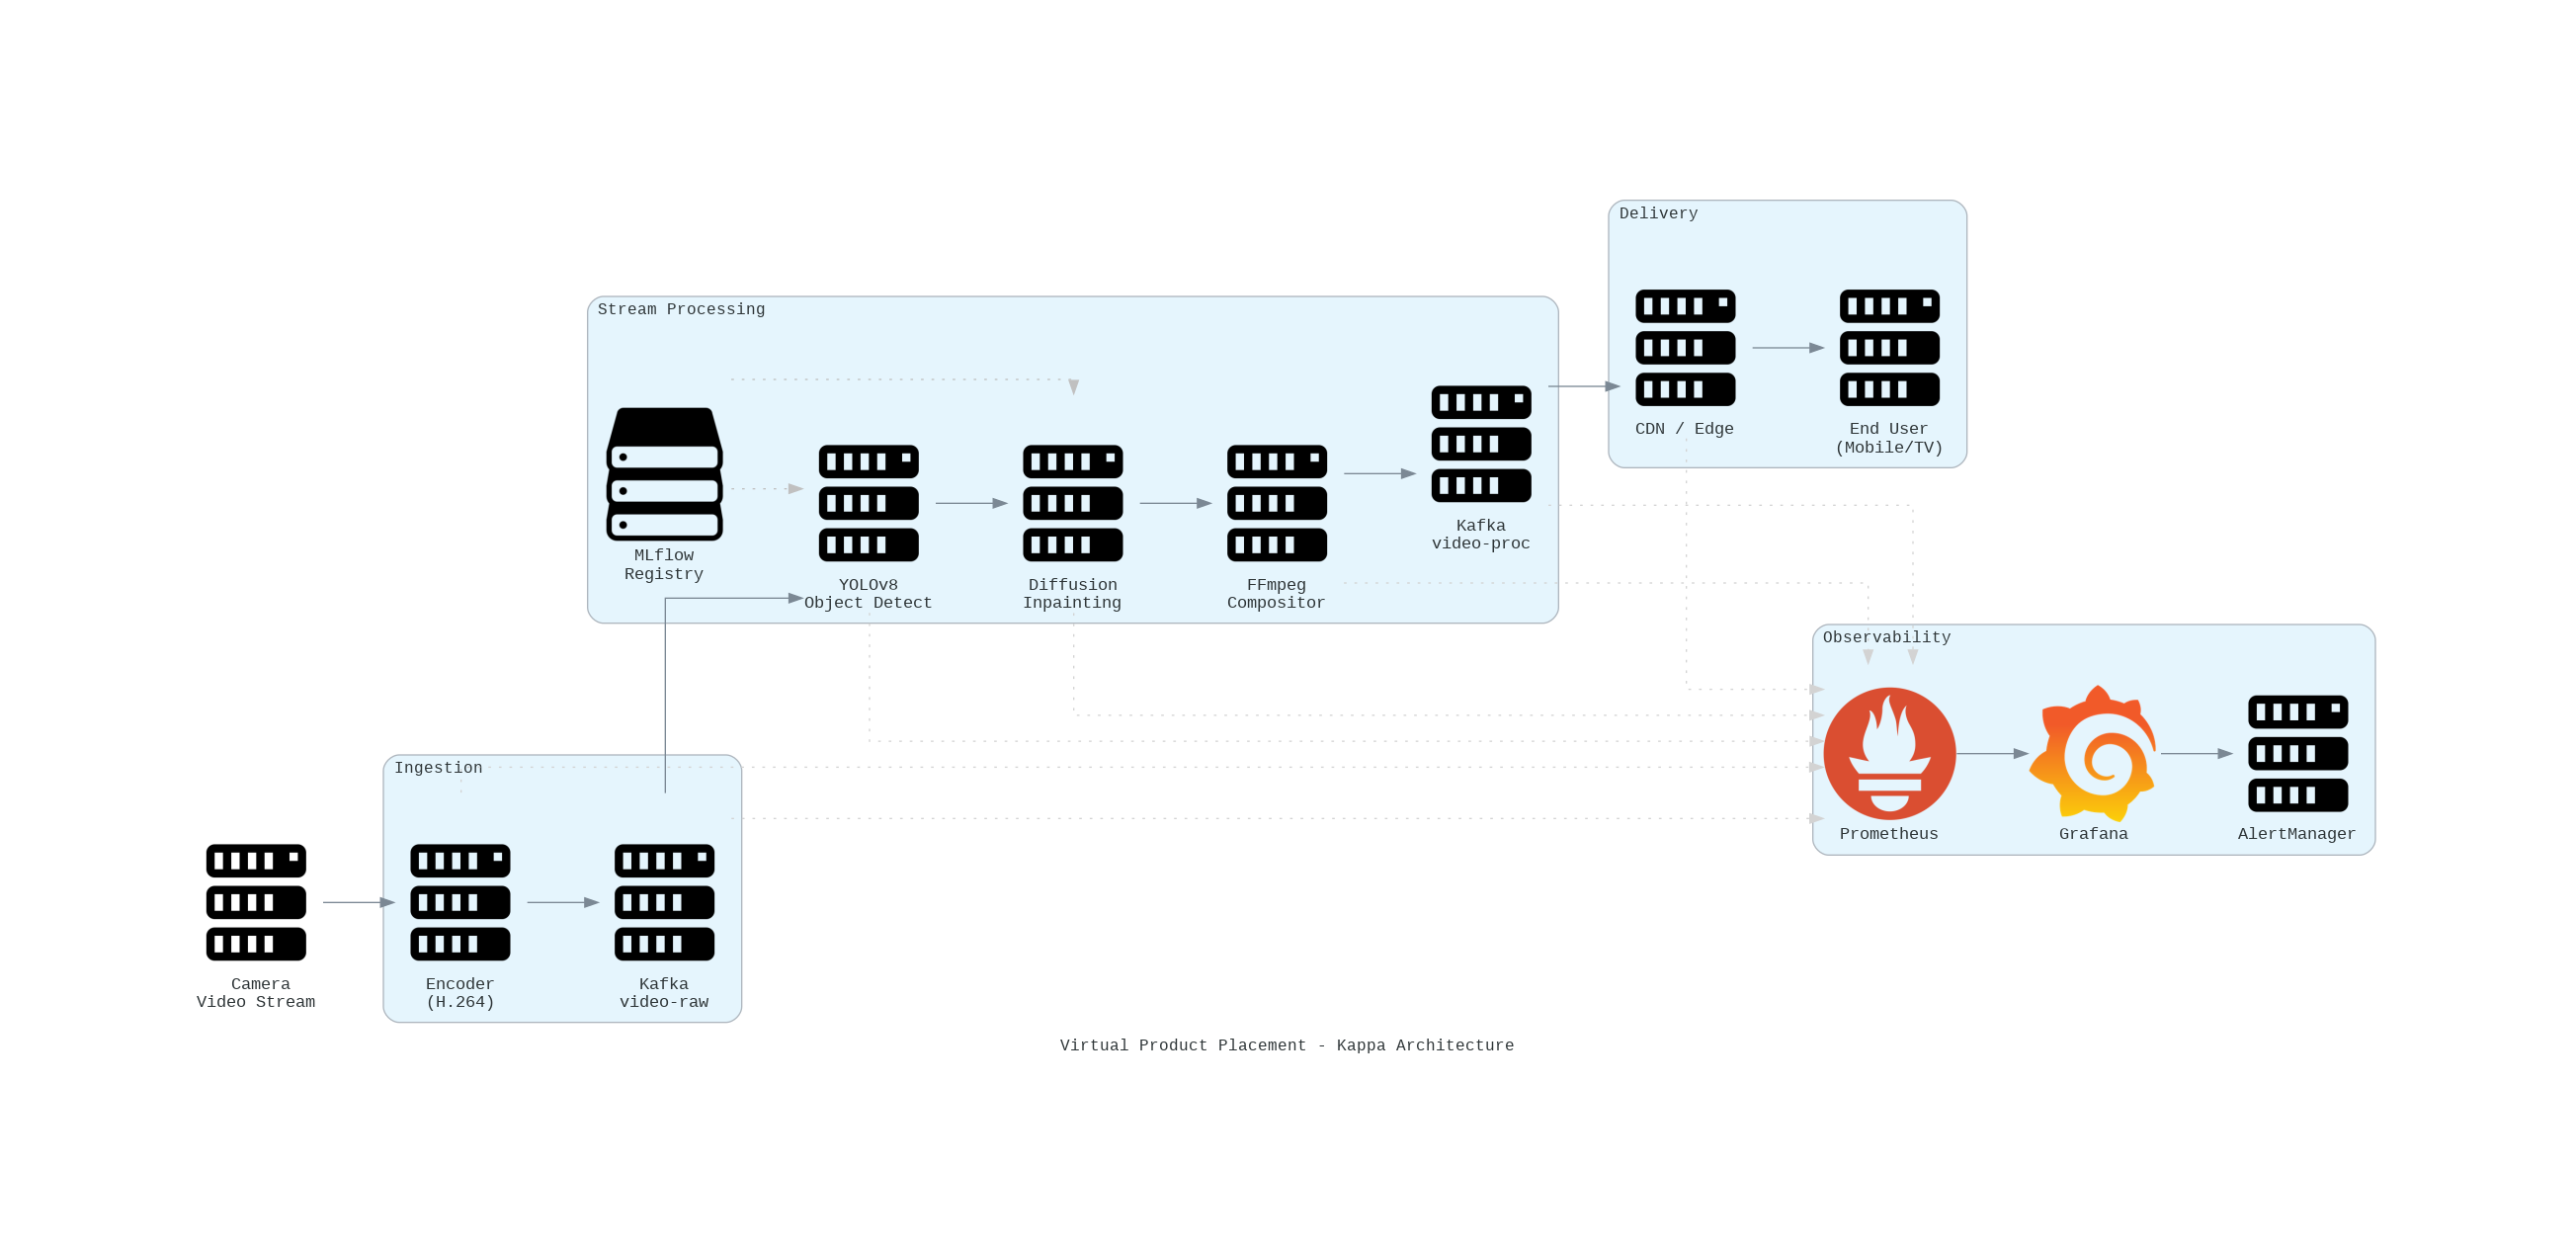

In [14]:
graph_attr = {"fontsize": "12", "bgcolor": "white", "splines": "ortho"}

with Diagram("Virtual Product Placement - Kappa Architecture",
           filename="vpp_architecture",
           direction="LR",
           show=False,
           graph_attr=graph_attr) as diag:

    camera = Server(" Camera\nVideo Stream")

    with Cluster("Ingestion"):
        encoder = Server("Encoder\n(H.264)")
        kafka_in = Server("Kafka\nvideo-raw")

    with Cluster("Stream Processing"):
        yolo = Server("YOLOv8\nObject Detect")
        ai_gen = Server("Diffusion\nInpainting")
        ffmpeg = Server("FFmpeg\nCompositor")
        kafka_out = Server("Kafka\nvideo-proc")
        registry = Storage("MLflow\nRegistry")

    with Cluster("Delivery"):
        cdn = Server("CDN / Edge")
        user = Server("End User\n(Mobile/TV)")

    with Cluster("Observability"):
        prom = Prometheus("Prometheus")
        graf = Grafana("Grafana")
        alert = Server("AlertManager")

    camera >> encoder >> kafka_in >> yolo >> ai_gen >> ffmpeg >> kafka_out >> cdn >> user
    registry >> Edge(style="dotted", color="gray") >> yolo
    registry >> Edge(style="dotted", color="gray") >> ai_gen

    for node in [encoder, kafka_in, yolo, ai_gen, ffmpeg, kafka_out, cdn]:
        node >> Edge(style="dotted", color="lightgray") >> prom
    prom >> graf >> alert

display(Image("vpp_architecture.png", width=1100))